# Flight Delay Propagation Across 2024

This notebook extends the baseline Markov-chain workflow to the full 2024 dataset.

I use 2024 as the main comparison year because the 2025 sample was affected by a federal government shutdown period of an unprecedented length, which makes that window less useful for broad comparison or generalization.

The objective is to compare long-run delay behavior across months and major U.S. airlines using the same state definitions and transition framework from the July 2025 analysis.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

import airportsdata

import glob
import os
import gc


In [2]:
#load in 2024 data
folder_path = 'data/2024_data'
files_2024 = glob.glob(os.path.join(folder_path, "*.csv"))

df_list = [pd.read_csv(f) for f in files_2024]
df_2024 = pd.concat(df_list, ignore_index=True)

In [3]:
# drop null tail numbers in accordance with previous analysis
df_2024 = df_2024.dropna(subset="TAIL_NUM")
df_2024.info()

<class 'pandas.DataFrame'>
Index: 7522467 entries, 0 to 7546987
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   DAY_OF_WEEK            int64  
 1   FL_DATE                str    
 2   OP_CARRIER_AIRLINE_ID  int64  
 3   TAIL_NUM               str    
 4   ORIGIN                 str    
 5   ORIGIN_CITY_NAME       str    
 6   DEST                   str    
 7   DEST_CITY_NAME         str    
 8   CRS_DEP_TIME           int64  
 9   DEP_TIME               float64
 10  DEP_DELAY              float64
 11  ARR_TIME               float64
 12  ARR_DELAY              float64
 13  ARR_DELAY_NEW          float64
 14  CANCELLED              float64
 15  DIVERTED               float64
 16  DUP                    str    
 17  CRS_ELAPSED_TIME       float64
 18  ACTUAL_ELAPSED_TIME    float64
dtypes: float64(9), int64(3), str(7)
memory usage: 1.1 GB


## Time Handling

This section repeats the time-normalization workflow from the baseline notebook so the full-year analysis uses the same operational-day definition and UTC ordering rules.

In [4]:
#convert FL_DATE to datetime
df_2024['FL_DATE'] = pd.to_datetime(df_2024['FL_DATE'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

#Format local CRS departure time 

#pad to 4 digits
df_2024['CRS_DEP_LT'] = pd.to_numeric(df_2024['CRS_DEP_TIME'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(4)

#replace flights at midnight with 2359 for dt handling
df_2024['CRS_DEP_LT'] = df_2024['CRS_DEP_LT'].replace('2400', '2359')

#convert to datetime
df_2024['CRS_DEP_LT'] = pd.to_datetime(df_2024['FL_DATE'].dt.strftime('%Y-%m-%d') + ' ' + df_2024['CRS_DEP_LT'].str[:2] + ':' + df_2024['CRS_DEP_LT'].str[2:], format='%Y-%m-%d %H:%M', errors='coerce')
df_2024.head()

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,ARR_TIME,ARR_DELAY,ARR_DELAY_NEW,CANCELLED,DIVERTED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,CRS_DEP_LT
0,1,2024-11-04,19393,N1801U,HNL,"Honolulu, HI",KOA,"Kona, HI",1200,1154.0,-6.0,1238.0,-17.0,0.0,0.0,0.0,N,55.0,44.0,2024-11-04 12:00:00
1,1,2024-11-04,19393,N1801U,KOA,"Kona, HI",OGG,"Kahului, HI",1415,1408.0,-7.0,1440.0,-20.0,0.0,0.0,0.0,N,45.0,32.0,2024-11-04 14:15:00
2,1,2024-11-04,19393,N1801U,LAX,"Los Angeles, CA",HNL,"Honolulu, HI",705,704.0,-1.0,1040.0,-35.0,0.0,0.0,0.0,N,370.0,336.0,2024-11-04 07:05:00
3,1,2024-11-04,19393,N1801U,OGG,"Kahului, HI",LIH,"Lihue, HI",1545,1531.0,-14.0,1620.0,-20.0,0.0,0.0,0.0,N,55.0,49.0,2024-11-04 15:45:00
4,1,2024-11-04,19393,N1802U,AUS,"Austin, TX",TPA,"Tampa, FL",1420,1433.0,13.0,1749.0,14.0,14.0,0.0,0.0,N,135.0,136.0,2024-11-04 14:20:00


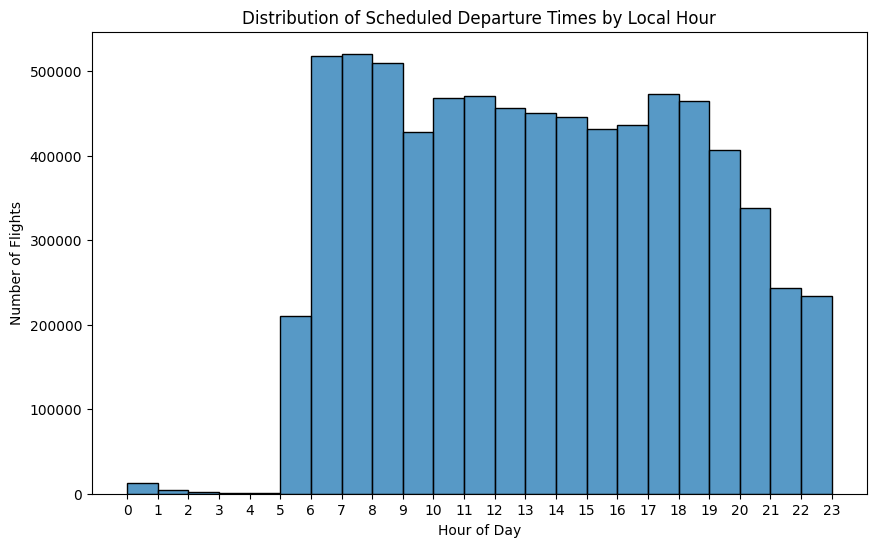

In [5]:
# plot distribution of departure times by the hour
plt.figure(figsize=(10,6))
sns.histplot(df_2024['CRS_DEP_LT'].dt.hour, bins=23, kde=False)
plt.title('Distribution of Scheduled Departure Times by Local Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Flights')
plt.xticks(range(0,24))
plt.show()
plt.close()

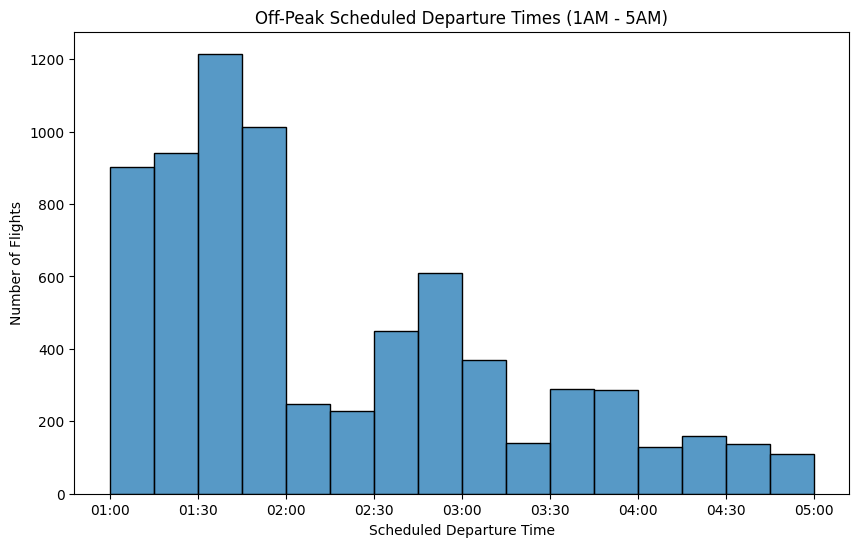

357

In [6]:
# plot off-peak departure in 15 minute intervals (1am-4am)
off_hour_flights = df_2024[ (df_2024['CRS_DEP_LT'].dt.hour < 5) & (df_2024['CRS_DEP_LT'].dt.hour >= 1) ]

off_hour_flights['minutes_of_day'] = (off_hour_flights['CRS_DEP_LT'].dt.hour * 60 + off_hour_flights['CRS_DEP_LT'].dt.minute)

plt.figure(figsize=(10,6))
sns.histplot(
    data=off_hour_flights, 
    x='minutes_of_day', 
    bins=range(60, 315, 15),
    kde=False
)

ticks = range(60, 315, 30)
labels = [f"{m//60:02d}:{m%60:02d}" for m in ticks]
plt.xticks(ticks, labels)

plt.title('Off-Peak Scheduled Departure Times (1AM - 5AM)')
plt.xlabel('Scheduled Departure Time')
plt.ylabel('Number of Flights')
plt.show()
plt.close()

#cleanup
del off_hour_flights
gc.collect()

Unlike the July 2025 subset, the 2024 data includes a few departures after 3:45 AM. Even so, system-wide volume still bottoms out in the pre-dawn window before rising sharply around 5:00 AM.

For consistency and operational realism, we keep the 5:00 AM to 5:00 AM day boundary.

In [7]:
df_2024['Operational_Date'] = (df_2024['CRS_DEP_LT'] - pd.Timedelta(hours=5)).dt.date

# Calculate universal departure time
airports = airportsdata.load('IATA')
df_2024['CRS_DEP_UTC'] = pd.NaT

def get_tz(iata_code):
    return airports[iata_code]['tz']

df_2024['DEP_TZ'] = df_2024['ORIGIN'].apply(get_tz)

#process timezones in groups
for tz, group in df_2024.groupby('DEP_TZ'):
    utc = (group['CRS_DEP_LT'].dt.tz_localize(tz, ambiguous='NaT', nonexistent='NaT').dt.tz_convert('UTC').dt.tz_localize(None))

    df_2024.loc[group.index, 'CRS_DEP_UTC'] = utc

df_2024.head()

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_TIME,...,ARR_DELAY_NEW,CANCELLED,DIVERTED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,CRS_DEP_LT,Operational_Date,CRS_DEP_UTC,DEP_TZ
0,1,2024-11-04,19393,N1801U,HNL,"Honolulu, HI",KOA,"Kona, HI",1200,1154.0,...,0.0,0.0,0.0,N,55.0,44.0,2024-11-04 12:00:00,2024-11-04,2024-11-04 22:00:00,Pacific/Honolulu
1,1,2024-11-04,19393,N1801U,KOA,"Kona, HI",OGG,"Kahului, HI",1415,1408.0,...,0.0,0.0,0.0,N,45.0,32.0,2024-11-04 14:15:00,2024-11-04,2024-11-05 00:15:00,Pacific/Honolulu
2,1,2024-11-04,19393,N1801U,LAX,"Los Angeles, CA",HNL,"Honolulu, HI",705,704.0,...,0.0,0.0,0.0,N,370.0,336.0,2024-11-04 07:05:00,2024-11-04,2024-11-04 15:05:00,America/Los_Angeles
3,1,2024-11-04,19393,N1801U,OGG,"Kahului, HI",LIH,"Lihue, HI",1545,1531.0,...,0.0,0.0,0.0,N,55.0,49.0,2024-11-04 15:45:00,2024-11-04,2024-11-05 01:45:00,Pacific/Honolulu
4,1,2024-11-04,19393,N1802U,AUS,"Austin, TX",TPA,"Tampa, FL",1420,1433.0,...,14.0,0.0,0.0,N,135.0,136.0,2024-11-04 14:20:00,2024-11-04,2024-11-04 20:20:00,America/Chicago


In [8]:
# Create actual depature time in local time
df_2024['DEP_TIME_LT'] = df_2024['CRS_DEP_LT'] + pd.to_timedelta(df_2024['DEP_DELAY'], unit='m')
df_2024.head()

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_TIME,...,CANCELLED,DIVERTED,DUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,CRS_DEP_LT,Operational_Date,CRS_DEP_UTC,DEP_TZ,DEP_TIME_LT
0,1,2024-11-04,19393,N1801U,HNL,"Honolulu, HI",KOA,"Kona, HI",1200,1154.0,...,0.0,0.0,N,55.0,44.0,2024-11-04 12:00:00,2024-11-04,2024-11-04 22:00:00,Pacific/Honolulu,2024-11-04 11:54:00
1,1,2024-11-04,19393,N1801U,KOA,"Kona, HI",OGG,"Kahului, HI",1415,1408.0,...,0.0,0.0,N,45.0,32.0,2024-11-04 14:15:00,2024-11-04,2024-11-05 00:15:00,Pacific/Honolulu,2024-11-04 14:08:00
2,1,2024-11-04,19393,N1801U,LAX,"Los Angeles, CA",HNL,"Honolulu, HI",705,704.0,...,0.0,0.0,N,370.0,336.0,2024-11-04 07:05:00,2024-11-04,2024-11-04 15:05:00,America/Los_Angeles,2024-11-04 07:04:00
3,1,2024-11-04,19393,N1801U,OGG,"Kahului, HI",LIH,"Lihue, HI",1545,1531.0,...,0.0,0.0,N,55.0,49.0,2024-11-04 15:45:00,2024-11-04,2024-11-05 01:45:00,Pacific/Honolulu,2024-11-04 15:31:00
4,1,2024-11-04,19393,N1802U,AUS,"Austin, TX",TPA,"Tampa, FL",1420,1433.0,...,0.0,0.0,N,135.0,136.0,2024-11-04 14:20:00,2024-11-04,2024-11-04 20:20:00,America/Chicago,2024-11-04 14:33:00


## Assign States to Flights

Each flight is mapped to a discrete state so aircraft-day sequences can be modeled as Markov chains.

State definitions:

0. On-time: `ARR_DELAY < 15`
1. Delayed: `ARR_DELAY >= 15`
2. Significant delay: `ARR_DELAY >= 60`
3. Extreme departure delay: `DEP_DELAY >= 120`
4. Cancelled flight
5. Diverted flight

State `3` is used to represent severe disruption likely to carry forward to downstream legs.

In [9]:
#classify flights as delayed or not 
df_2024['IS_ARR_DELAY'] = df_2024['ARR_DELAY'] >= 15

# set state variable for modeling
df_2024['STATE'] = df_2024['IS_ARR_DELAY'] * 1
extreme_mask = df_2024['ARR_DELAY'] >= 60
df_2024.loc[extreme_mask, 'STATE'] = 2

# define sequence failures
cancelled_mask = df_2024['CANCELLED'] == 1
diverted_mask = df_2024['DIVERTED'] == 1
extreme_mask = df_2024['DEP_DELAY'] >= 120

df_2024.loc[extreme_mask, 'STATE'] = 3
df_2024.loc[cancelled_mask, 'STATE'] = 4
df_2024.loc[diverted_mask, 'STATE'] = 5

df_2024.STATE.value_counts()

STATE
0    5894155
1     987734
2     321816
3     221544
4      78387
5      18831
Name: count, dtype: int64

## Assign Flights to Chains

A chain is one aircraft (`TAIL_NUM`) observed over one operational day (`Operational_Date`).

Flights are sorted by scheduled UTC departure and grouped into ordered sequences for transition estimation.

In [10]:
# flights to inorder of scheduled departure time in UTC
df_2024 = df_2024.sort_values(by=['TAIL_NUM', 'Operational_Date', 'CRS_DEP_UTC', 'STATE'])

# remove cases of ghost flights, a flight was cancelled, but the aircraft was scheduled for another flight at the same time
df_2024 = df_2024.drop_duplicates(subset=['TAIL_NUM', 'Operational_Date', 'CRS_DEP_UTC'], keep='first')

# assign an ID to each chain
df_2024['CHAIN_ID'] = df_2024.groupby(['TAIL_NUM', 'Operational_Date']).ngroup()

Number of chains: 1821438


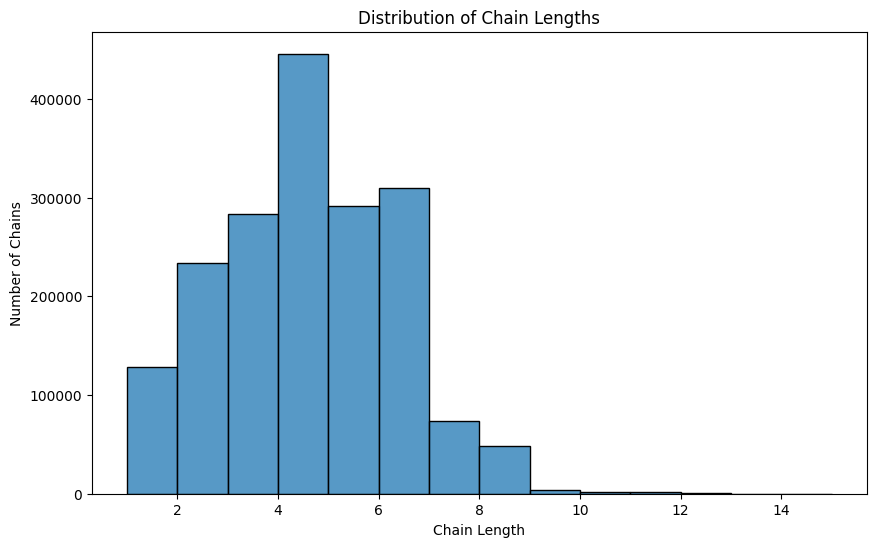

1     128361
2     233342
3     283087
4     445784
5     291132
6     309906
7      73343
8      48809
9       4013
10      1899
11      1447
12       279
13        34
14         1
15         1
Name: count, dtype: int64


In [11]:
# count the number of chains
print("Number of chains:", df_2024['CHAIN_ID'].nunique())

# plot distribution of chain lengths
chain_lengths = df_2024.groupby('CHAIN_ID').size()
plt.figure(figsize=(10,6))
sns.histplot(chain_lengths, bins=range(1, chain_lengths.max() + 1), kde=False)
plt.title('Distribution of Chain Lengths')
plt.xlabel('Chain Length')
plt.ylabel('Number of Chains')
plt.show()
plt.close()

# count number of chains of each length
chain_length_counts = chain_lengths.value_counts().sort_index()
print(chain_length_counts)

The chain-length profile is similar to the July 2025 sample: most aircraft complete about 4 flights per operating day, and counts taper noticeably after 6 flights.

In [12]:
df_2024[df_2024['CHAIN_ID'] == 654321]

,DAY_OF_WEEK,FL_DATE,OP_CARRIER_AIRLINE_ID,TAIL_NUM,ORIGIN,ORIGIN_CITY_NAME,DEST,DEST_CITY_NAME,CRS_DEP_TIME,DEP_TIME,...,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,CRS_DEP_LT,Operational_Date,CRS_DEP_UTC,DEP_TZ,DEP_TIME_LT,IS_ARR_DELAY,STATE,CHAIN_ID
6231318,1,2024-05-06,19930,N413AS,SAT,"San Antonio, TX",SEA,"Seattle, WA",700,701.0,...,267.0,262.0,2024-05-06 07:00:00,2024-05-06,2024-05-06 12:00:00,America/Chicago,2024-05-06 07:01:00,False,0,654321
6231320,1,2024-05-06,19930,N413AS,SEA,"Seattle, WA",SMF,"Sacramento, CA",1000,1023.0,...,114.0,110.0,2024-05-06 10:00:00,2024-05-06,2024-05-06 17:00:00,America/Los_Angeles,2024-05-06 10:23:00,True,1,654321
6231321,1,2024-05-06,19930,N413AS,SMF,"Sacramento, CA",SEA,"Seattle, WA",1249,1301.0,...,121.0,122.0,2024-05-06 12:49:00,2024-05-06,2024-05-06 19:49:00,America/Los_Angeles,2024-05-06 13:01:00,False,0,654321
6231319,1,2024-05-06,19930,N413AS,SEA,"Seattle, WA",SJC,"San Jose, CA",1545,1603.0,...,128.0,126.0,2024-05-06 15:45:00,2024-05-06,2024-05-06 22:45:00,America/Los_Angeles,2024-05-06 16:03:00,True,1,654321


## Transition Matrix

This section estimates the one-step transition matrix for the full 2024 dataset. Each entry gives the probability of moving from one state to another on the next flight leg.

In [13]:
# create a column for the next state in the chain
df_2024['NEXT_STATE'] = df_2024.groupby('CHAIN_ID')['STATE'].shift(-1)
transitions = df_2024.dropna(subset=['NEXT_STATE'])

transition_matrix = pd.crosstab(
    transitions['STATE'],       
    transitions['NEXT_STATE'], 
    normalize='index' 
).round(4)

print(transition_matrix)

NEXT_STATE     0.0     1.0     2.0     3.0     4.0     5.0
STATE                                                     
0           0.8614  0.0969  0.0221  0.0131  0.0041  0.0024
1           0.4437  0.4358  0.0788  0.0278  0.0108  0.0031
2           0.1190  0.2877  0.4487  0.1158  0.0253  0.0035
3           0.1962  0.0959  0.1599  0.4883  0.0564  0.0033
4           0.3002  0.1294  0.0792  0.0847  0.4036  0.0030
5           0.0883  0.0749  0.1394  0.5633  0.1283  0.0058


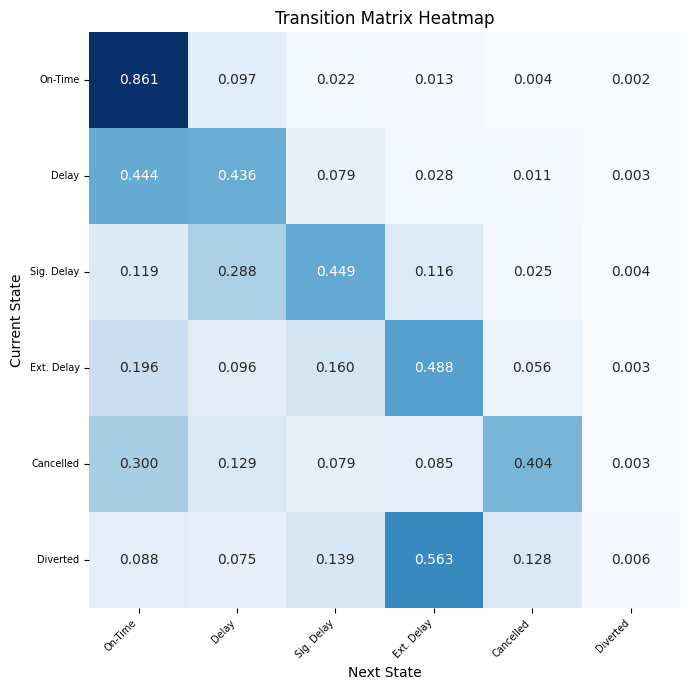

In [14]:
labels = ['On-Time', 'Delay', 'Sig. Delay', 'Ext. Delay', 'Cancelled', 'Diverted']

plt.figure(figsize=(7, 7))
sns.heatmap(transition_matrix, annot=True, fmt='.3f', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar=False)
plt.title('Transition Matrix Heatmap')
plt.xlabel('Next State')
plt.ylabel('Current State')

plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)

plt.tight_layout()
plt.show()
plt.close()

Delay-propagation patterns remain directionally similar to July 2025, but the full-year 2024 matrix suggests stronger recovery from delayed states.

In other words, delayed operations were more likely to return to less severe states in 2024 than during the July 2025 peak window.

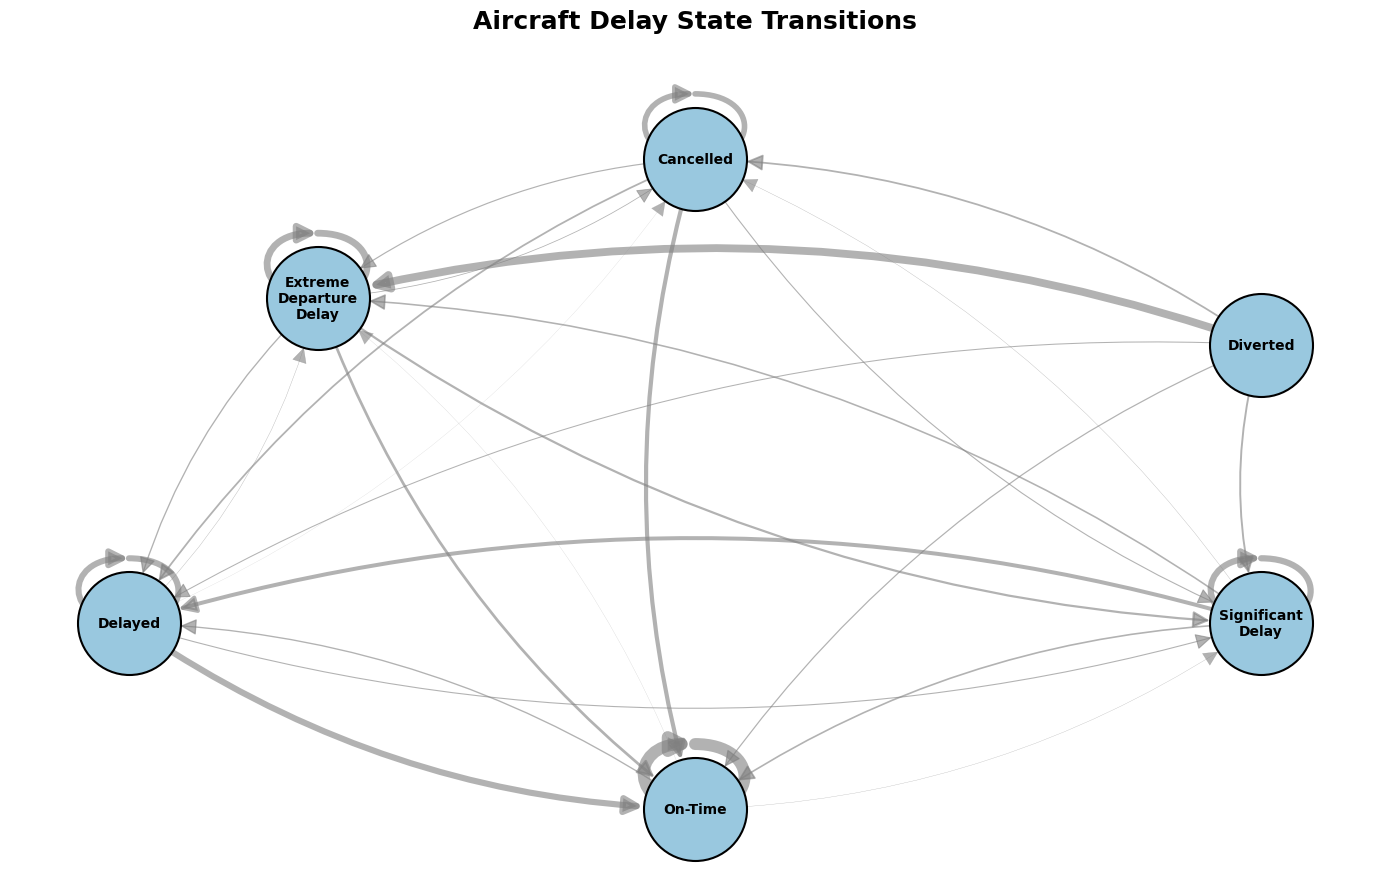

In [15]:
# Visualize directed graph
dg = nx.DiGraph()

state_labels = {
    0.0: 'On-Time',
    1.0: 'Delayed',
    2.0: 'Significant\nDelay',
    3.0: 'Extreme\nDeparture\nDelay',
    4.0: 'Cancelled',
    5.0: 'Diverted'
}

# for simiplicity only show transitions above 1%
threshold = .01

for current_state in transition_matrix.index:
    for next_state in transition_matrix.columns:
        prob = transition_matrix.loc[current_state, next_state]
        
        if prob >= threshold:
            dg.add_edge(
                state_labels[current_state], 
                state_labels[next_state], 
                weight=prob
            )

pos = {
    'On-Time': (0, -3),         
    'Delayed': (-3, -1),        
    'Extreme\nDeparture\nDelay': (-2, 2.5),
    'Cancelled': (0, 4),        
    'Diverted': (3, 2),         
    'Significant\nDelay': (3, -1)  
}

edge_widths = [dg[u][v]['weight'] * 10 for u, v in dg.edges()]

plt.figure(figsize=(14, 9))
nx.draw_networkx_edges(
    dg, pos, 
    node_size=5500,           
    width=edge_widths, 
    arrowstyle='-|>', 
    arrowsize=25, 
    edge_color='gray', 
    alpha=0.6,
    connectionstyle='arc3,rad=0.15' 
)

nx.draw_networkx_nodes(
    dg, pos, 
    node_size=5500, 
    node_color='#99C8DF', 
    edgecolors='black', 
    linewidths=1.5
)

nx.draw_networkx_labels(dg, pos, font_size=10, font_weight='bold')

plt.title("Aircraft Delay State Transitions", fontsize=18, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()
plt.close()

## Stationary Distribution

The stationary distribution summarizes the long-run share of flights in each state under the estimated transition dynamics.

In [16]:
# Calculate stationary distribution with eigen decomposition
matrix = transition_matrix.to_numpy()

eigenvalues, eigenvectors = np.linalg.eig(matrix.T)

eigenvalue_index = np.argmin(np.abs(eigenvalues - 1.0))
steady_state_vector = eigenvectors[:, eigenvalue_index]
stationary_distribution = steady_state_vector / np.sum(steady_state_vector)

for state_id, prob in zip(transition_matrix.columns, stationary_distribution):
    label = state_labels[state_id].replace('\n', ' ')
    print(f"{label:<24}: {prob:.2%}")

On-Time                 : 69.77%
Delayed                 : 16.70%
Significant Delay       : 6.87%
Extreme Departure Delay : 4.80%
Cancelled               : 1.58%
Diverted                : 0.27%


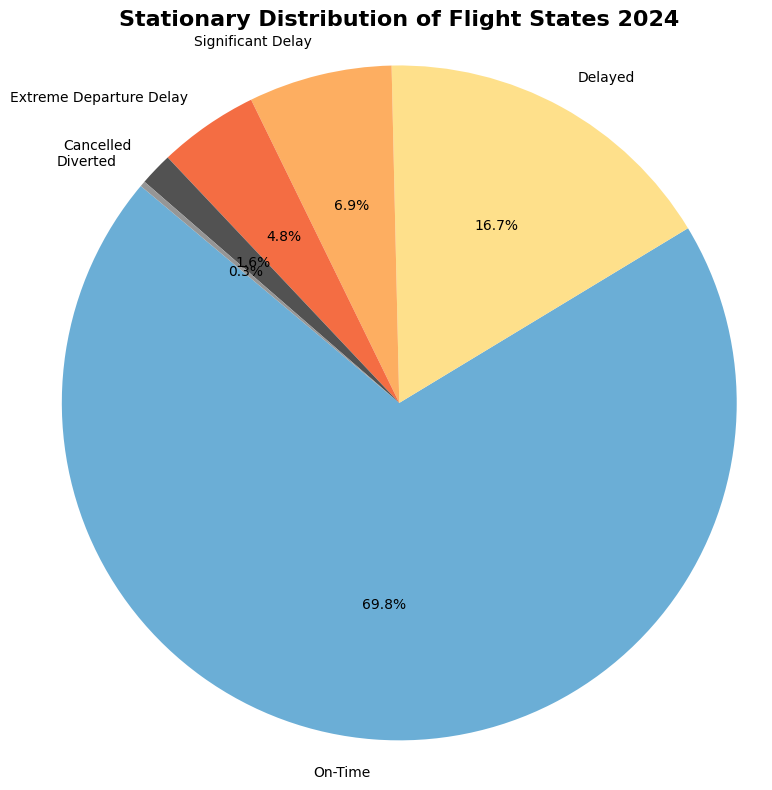

In [17]:
# pie chart of stationary distribution
labels = state_labels.values()
labels = [x.replace('\n', ' ') for x in labels]
colors = ['#6BAED6', '#FEE08B', '#FDAE61', '#F46D43', '#525252', '#969696']

plt.figure(figsize=(8, 8))
plt.pie(stationary_distribution, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Stationary Distribution of Flight States 2024', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()
plt.close()

## Seasonal Stationary Distribution

To examine seasonality, we compute a monthly stationary distribution for each month of 2024.

This gives a consistent way to compare how the long-run delay mix changes throughout the year.

In [18]:
# group data my months
df_2024['MONTH'] = pd.to_datetime(df_2024['Operational_Date']).dt.month

state_labels = {
    0.0: 'On-Time',
    1.0: 'Delayed',
    2.0: 'Significant Delay',
    3.0: 'Extreme Departure Delay',
    4.0: 'Cancelled',
    5.0: 'Diverted'
}

monthly_steady_states = {label: [] for label in state_labels.values()}

for month_num, df_month in df_2024.groupby('MONTH'):
    
    month_transitions = df_month.dropna(subset=['NEXT_STATE'])
    transition_counts = month_transitions.groupby(['STATE', 'NEXT_STATE']).size().unstack(fill_value=0)
    transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)

    # calculate stationary distribution
    matrix = transition_matrix.to_numpy()
    eigenvalues, eigenvectors = np.linalg.eig(matrix.T)
    idx = np.argmin(np.abs(eigenvalues - 1.0))
    steady_state_vector = np.real(eigenvectors[:, idx])
    stationary_distribution = steady_state_vector / np.sum(steady_state_vector)

    for state_id, prob in zip(transition_matrix.columns, stationary_distribution):
        label = state_labels[state_id]
        monthly_steady_states[label].append(prob)

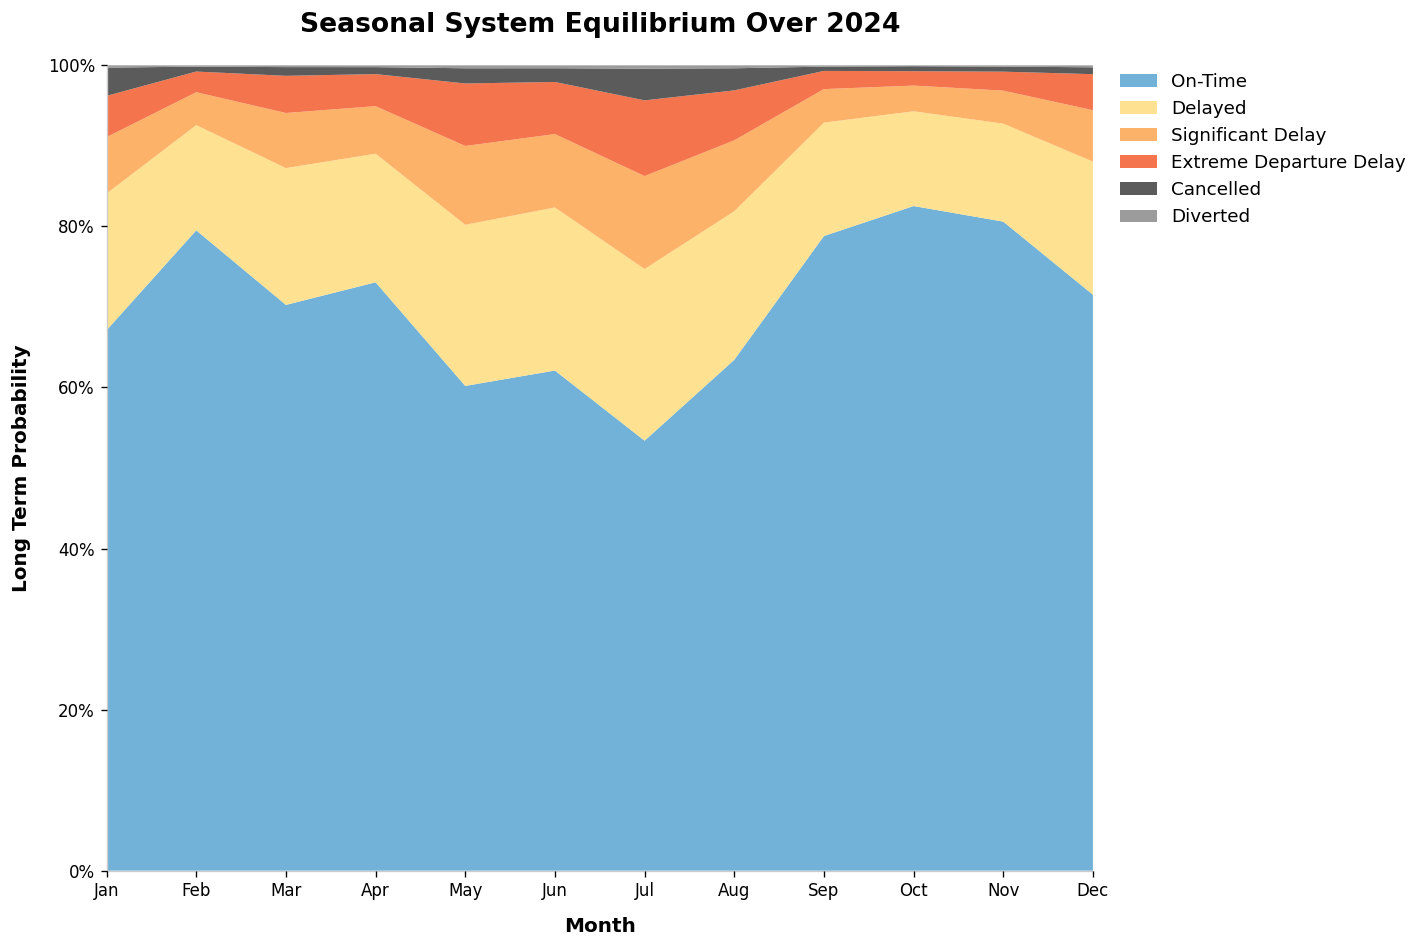

In [19]:
# plot monthly stationary distribution
from matplotlib.ticker import PercentFormatter

months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
colors = ['#6BAED6', '#FEE08B', '#FDAE61', '#F46D43', '#525252', '#969696']

fig, ax = plt.subplots(figsize=(12, 8), dpi=120)

plt.stackplot(
    months_labels, 
    monthly_steady_states['On-Time'],
    monthly_steady_states['Delayed'],
    monthly_steady_states['Significant Delay'],
    monthly_steady_states['Extreme Departure Delay'],
    monthly_steady_states['Cancelled'],
    monthly_steady_states['Diverted'],
    labels=['On-Time', 'Delayed', 'Significant Delay', 'Extreme Departure Delay', 'Cancelled', 'Diverted'],
    colors=colors,
    alpha=0.95
)

plt.title("Seasonal System Equilibrium Over 2024", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Month", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Long Term Probability", fontsize=12, fontweight='bold', labelpad=10)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.ylim(0, 1)
plt.xlim(months_labels[0], months_labels[-1])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

ax.set_axisbelow(False)

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=False, fontsize=11)

plt.tight_layout()
plt.show()
plt.close()

The monthly comparison suggests summer, especially July, has the weakest long-run on-time equilibrium, while several fall months show stronger performance.

## Performance by Operating Airline

This section compares stationary distributions for four major U.S. airlines:
- American
- Delta
- Southwest
- United

The comparison uses `OP_CARRIER_AIRLINE_ID`, the DOT-issued identifier for each operating carrier.

In [20]:
# calculate the stationary distribution of the airlines of interest
target_airlines = {
    19790: 'Delta',
    19977: 'United',
    19393: 'Southwest',
    19805: 'American'
}

state_labels_list = ['On-Time', 'Delayed', 'Significant Delay', 'Extreme Departure Delay', 'Cancelled', 'Diverted']
airline_steady_states = {name: [] for name in target_airlines.values()}

df_big4 = df_2024[df_2024['OP_CARRIER_AIRLINE_ID'].isin(target_airlines.keys())].copy()

for airline_id, df_airline in df_big4.groupby('OP_CARRIER_AIRLINE_ID'):
    
    airline_name = target_airlines[airline_id]
    
    valid_transitions = df_airline.dropna(subset=['NEXT_STATE'])
    transition_counts = valid_transitions.groupby(['STATE', 'NEXT_STATE']).size().unstack(fill_value=0)
    transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)
    
    # Calculate stationary distribution
    matrix = transition_matrix.to_numpy()
    eigenvalues, eigenvectors = np.linalg.eig(matrix.T)
    idx = np.argmin(np.abs(eigenvalues - 1.0))
    steady_state_vector = np.real(eigenvectors[:, idx])
    stationary_distribution = steady_state_vector / np.sum(steady_state_vector)
    
    airline_steady_states[airline_name] = stationary_distribution

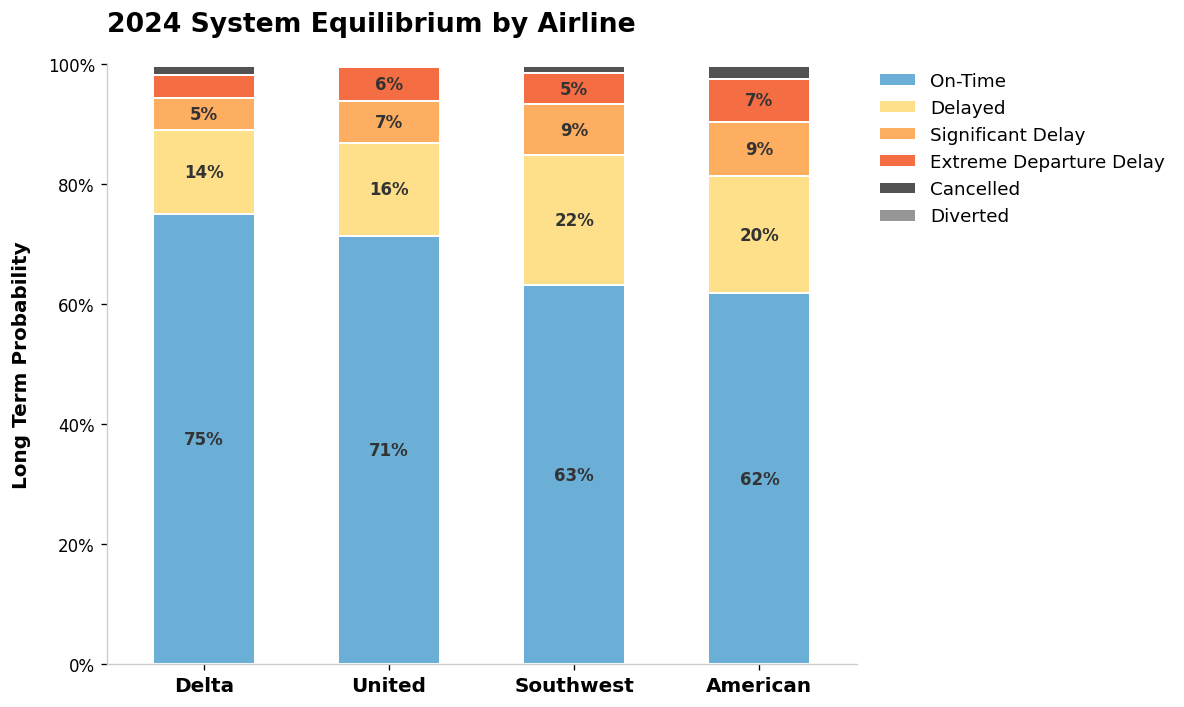

In [21]:
# plot the system equilibrium of each airline for comparison
df_plot = pd.DataFrame(airline_steady_states, index=state_labels_list).T

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
colors = ['#6BAED6', '#FEE08B', '#FDAE61', '#F46D43', '#525252', '#969696']

df_plot.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=colors, 
    edgecolor='white', 
    linewidth=1.2,
    width=0.55
)

for container in ax.containers:
    labels = [f"{v.get_height()*100:.0f}%" if v.get_height() > 0.04 else "" for v in container]
    ax.bar_label(
        container, 
        labels=labels, 
        label_type='center', 
        fontsize=10, 
        fontweight='bold', 
        color='#333333'
    )

ax.set_title("2024 System Equilibrium by Airline", fontsize=16, fontweight='bold', pad=20, loc='left')
ax.set_ylabel("Long Term Probability", fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=0, fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=False, fontsize=11)

plt.tight_layout()
plt.show()
plt.close()

The airline-level equilibrium comparison indicates Delta has the strongest long-run on-time profile in this sample, while Southwest and American show materially lower on-time shares.